# Regression Examples

Here we have example code and a bit of explanation for various regression models.  In particular, we have examples of

1. Logistic Regression
2. Simple Linear Regression
3. Multiple Linear Regression
4. Non-Linear Regression
5. Polynomial Regression

# Logistic Regression

Logistic regression is another algorithm we can try for predicting categorical values.  Algorithms like linear and multilinear regression are great at predicting continuous values, but for values that are categorical they present problems.  Logistic regression is particularly well-suited to predicting binary variables.

Logistic regression is a variation of linear regression and predicts the probability of a particular class label for the dependent variable based on the values of the independent variables.  It attempts to fit an S-shaped curve by taking the linear regression and transforming a numeric estimate into a probability using a sigmoid function.

A picture is worth a thousand words:

<img src="Logist_Regression_Image.png" width="400" align="center">

## Example of Predicting Customer Churn with Logistic Regression

This is an example on a toy dataset of a telecommunications carrier.  The example logistic model attempts to predict whether a customer is likely to leave the service.

First, import some libraries we like (pandas, numpy, pylab, matplotlib, and scikit-learn).
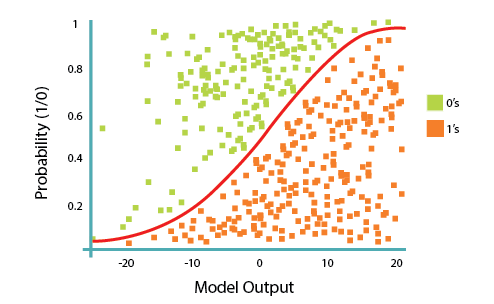

In [1]:
import pandas as pd
import numpy as np
import pylab as pl
import scipy.optimize as opt
from sklearn import preprocessing
import matplotlib.pyplot as plt

%matplotlib inline

### The Dataset

This a (toy) historical customer dataset with one customer per row.  We try to predict which customers are likely to terminate service with the company (since keeping customers is generally cheaper than acquiring new customers).  The dataset includes information on:

* Churn - Customers who left within the last month
* Services - The services a customer has, including
    * phone, 
    * multiple lines, 
    * internet, 
    * online security, 
    * online backup, 
    * device protection,
    * tech support,
    * streaming TV and movies
* Account information - Length of relationship, contract, payment method, paperless billing, monthly charges, total charges
* Demographic information - Gender, Age range, Parterns and Dependents

First, load the data into a pandas dataframe, then do some preprocessing to get things into usable formats

In [2]:
churn_df = pd.read_csv("ChurnData.csv")
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [3]:
# Cut out some columns we are not interested in and turn the Churn variable into an integer

churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'callcard', 'wireless', 'churn']]
churn_df['churn'] = churn_df['churn'].astype('int')
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


In [4]:
churn_df.shape

(200, 10)

In [5]:
# Create some numpy arrays for our data

X = np.asarray(churn_df[['tenure','age','address','income','ed','employ','equip']])
y = np.asarray(churn_df['churn'])

# Normalize the data

X = preprocessing.StandardScaler().fit(X).transform(X)
X[0:5]

array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695]])

In [6]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 4)

print("Train set: ", X_train.shape, y_train.shape)
print("Train set: ", X_test.shape, y_test.shape)

Train set:  (160, 7) (160,)
Train set:  (40, 7) (40,)


### Modeling using Logistic Regression and Scikit-Learn

We use functions from the scikit-learn package to build the logistic regression model.  We fit the model using the training set.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LR = LogisticRegression(C = 0.01, solver='liblinear').fit(X_train, y_train)
LR

LogisticRegression(C=0.01, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)

In [8]:
# Now we make predictions using the test set

yhat = LR.predict(X_test)
yhat

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

In [9]:
# Finally we use the **predict_proba** function to return the estimates. First column is prob of class 1, second columns is prob of class 2

yhat_prob = LR.predict_proba(X_test)
yhat_prob

array([[0.54132919, 0.45867081],
       [0.60593357, 0.39406643],
       [0.56277713, 0.43722287],
       [0.63432489, 0.36567511],
       [0.56431839, 0.43568161],
       [0.55386646, 0.44613354],
       [0.52237207, 0.47762793],
       [0.60514349, 0.39485651],
       [0.41069572, 0.58930428],
       [0.6333873 , 0.3666127 ],
       [0.58068791, 0.41931209],
       [0.62768628, 0.37231372],
       [0.47559883, 0.52440117],
       [0.4267593 , 0.5732407 ],
       [0.66172417, 0.33827583],
       [0.55092315, 0.44907685],
       [0.51749946, 0.48250054],
       [0.485743  , 0.514257  ],
       [0.49011451, 0.50988549],
       [0.52423349, 0.47576651],
       [0.61619519, 0.38380481],
       [0.52696302, 0.47303698],
       [0.63957168, 0.36042832],
       [0.52205164, 0.47794836],
       [0.50572852, 0.49427148],
       [0.70706202, 0.29293798],
       [0.55266286, 0.44733714],
       [0.52271594, 0.47728406],
       [0.51638863, 0.48361137],
       [0.71331391, 0.28668609],
       [0.

## Evaluation of the Model

We'll try two different evaluation techniques, the **jaccard index** and a **confusion matrix**.

In [10]:
from sklearn.metrics import jaccard_similarity_score
jaccard_similarity_score(y_test, yhat)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/metrics/_classification.py:664: FutureWarning: jaccard_similarity_score has been deprecated and replaced with jaccard_score. It will be removed in version 0.23. This implementation has surprising behavior for binary and multiclass classification tasks.
  FutureWarning)


0.75

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools


def plot_confusion_matrix (cm, classes, normalize = False, title = 'Confusion matrix', cmap = plt.cm.Blues):
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]
        print("Normalized Confusion Matrix")
    else:
        print("Confusion Matrix without Normalization")
    
    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 45)
    plt.yticks(tick_marks, classes)
    
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j], fmt), horizontalalignment = "center", color="white" if cm[i,j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

print(confusion_matrix(y_test, yhat, labels=[1,0]))

[[ 6  9]
 [ 1 24]]


Confusion Matrix without Normalization
[[ 6  9]
 [ 1 24]]


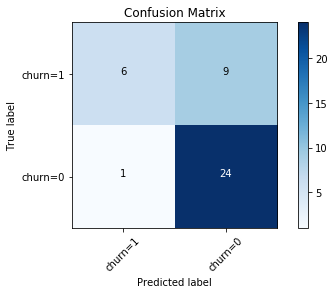

In [12]:
cnf_matrix = confusion_matrix(y_test, yhat, labels = [1,0])
np.set_printoptions(precision = 2)

plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'], normalize = False, title = "Confusion Matrix")

The confusion matrix gives us a nice, easy way to look at the accuracy of the predictions.  The first row of the matrix is for customers who actually left (Churn = 1).  There are 15 such customers.  Unfortunately, we only predicted 6 of them would churn and predicted 9 of them would not.  These 9 unpredicted churn cases are false negatives in the model (we falsely predicted they would not churn, when in fact they did).

The second row in the matrix shows that we did pretty well on predicting the customers who would not churn.  There were 25 non-churning customers, and we correctly 24 of them would not churn.  There was one customer we predicted would churn who did not.  This is a false positive of the model.

We can make a little summary report of the model performance.

In [13]:
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.73      0.96      0.83        25
           1       0.86      0.40      0.55        15

    accuracy                           0.75        40
   macro avg       0.79      0.68      0.69        40
weighted avg       0.78      0.75      0.72        40



A little explanation of the report.

* **Precision** measures the accuracy provided that we made a prediction.
* **Recall** is the true positive rate
* **F1 Score** is the harmonic average of the precision and recall.  The best possible value is 1 (perfect precision and recall) and the worst is 0. A good score indicates the model has good precision and recall.
* **Average accuracy** This is the average of both F1 scores.

One other evaluation metric is the log loss.  In logistic regression, the outputs are the probability of the predicted variable.  In this case, we actual make a probabilistic prediction of each customer's likelihood to churn.  This is a value between 0 and 1, so we can evaluate how accurate these probabilities were.  (Contrast with the above metric where we were just evaluating the binary prediction being correct or incorrect, so a 51% confidence was weighted the same in the evaluation as a 95% confidence.  Log loss will let us take the confidence of the model's prediction into account in our evaluation.)

In [14]:
from sklearn.metrics import log_loss
log_loss(y_test, yhat_prob)

0.6017092478101185

# Simple Linear Regression

Here we use a simple linear regression model on some sample fuel consumption data.  The goal of the model is to predict CO2 emissions of a vehicle based on Engine Size of the vehicle using a linear model.

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

In [16]:
df=pd.read_csv("FuelConsumptionCo2.csv")

df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [17]:
# Summarize the data set

df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [18]:
#Collect some features we care about into a dataframe

cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


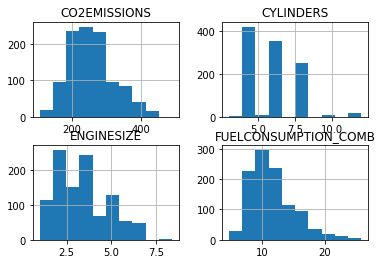

In [19]:
#Plot each of the features in the new dataframe

viz = cdf[['CYLINDERS', 'ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()

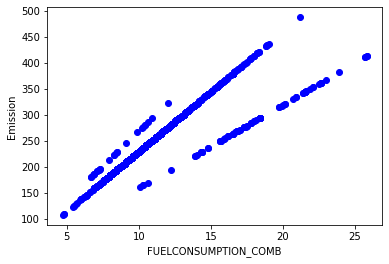

In [20]:
#Plot each of these features versus the CO2 emissions

plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

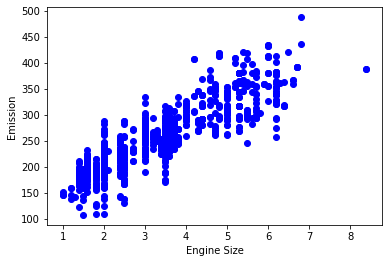

In [21]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine Size")
plt.ylabel("Emission")
plt.show()

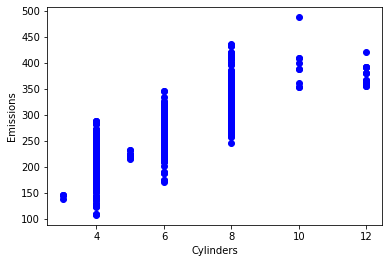

In [22]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Cylinders")
plt.ylabel("Emissions")
plt.show()

In [23]:
#Split the data into a training and testing set

msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

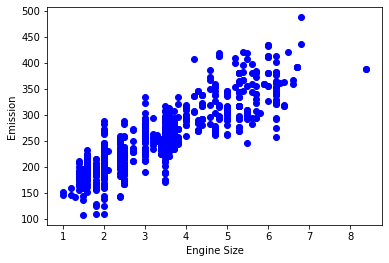

In [24]:
#Look at the training data distribution

plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.xlabel("Engine Size")
plt.ylabel("Emission")
plt.show()

In [25]:
#Using scikitlearn to model the data

from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit (train_x, train_y)
print('Coefficients: ', regr.coef_)
print('Intercept: ', regr.intercept_)

Coefficients:  [[38.59]]
Intercept:  [126.08]


Text(0, 0.5, 'Emission')

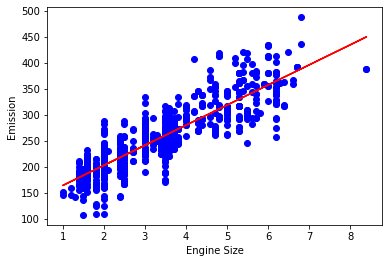

In [26]:
#Plot the outputs

plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine Size")
plt.ylabel("Emission")

In [27]:
#Evaluate the model

from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_hat = regr.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_hat - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_hat - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_hat, test_y) )

Mean absolute error: 21.69
Residual sum of squares (MSE): 839.41
R2-score: 0.69


# Multiple Linear Regression

An example of multiple linear regression using the same vehicle dataset.

In [28]:
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [29]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244
5,3.5,6,11.9,7.7,10.0,230
6,3.5,6,11.8,8.1,10.1,232
7,3.7,6,12.8,9.0,11.1,255
8,3.7,6,13.4,9.5,11.6,267


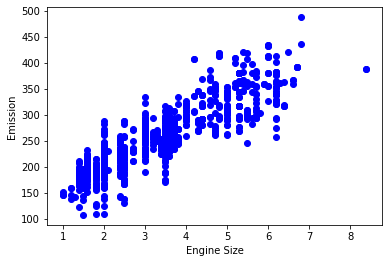

In [30]:
plt.scatter(cdf.ENGINESIZE,cdf.CO2EMISSIONS,color='blue')
plt.xlabel("Engine Size")
plt.ylabel("Emission")
plt.show()

In [31]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

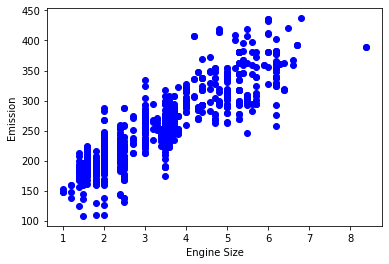

In [32]:
plt.scatter(train.ENGINESIZE,train.CO2EMISSIONS,color='blue')
plt.xlabel("Engine Size")
plt.ylabel("Emission")
plt.show()

In [33]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
x = np.asanyarray(train[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']])
y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit(x,y)
print('Coefficients: ', regr.coef_)

Coefficients:  [[11.54  7.42  9.25]]


In [34]:
y_hat = regr.predict(test[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']])
x = np.asanyarray(test[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']])
y = np.asanyarray(test[['CO2EMISSIONS']])
print("Residual sum of squares: %.2f" % np.mean((y_hat - y) ** 2))

print('Variance score: %.2f' % regr.score(x,y))

Residual sum of squares: 535.35
Variance score: 0.89


In [35]:
regr = linear_model.LinearRegression()
x = np.asanyarray(train[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY']])
y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit(x,y)
print('Coefficients: ', regr.coef_)
y_ = regr.predict(test[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','FUELCONSUMPTION_HWY']])
x = np.asanyarray(test[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']])
y = np.asanyarray(test[['CO2EMISSIONS']])
print("Residual sum of squres: %.2f" % np.mean((y_ - y) ** 2))
print("Variance score: %.2f" % regr.score(x,y))

Coefficients:  [[11.65  6.97  6.18  2.71]]
Residual sum of squres: 537.49
Variance score: 0.88


# Non Linear Regression

We use some non linear regression methods with numpy, scikit-learn, matplotlib to take a look at a model for China GDP growth from 1960 to 2014.  This is a toy dataset and is just illustrating the python code to do some nonlinear regression.

First we take a quick look at fitting a regression to a dataset with a linear relationship, then fitting a polynomial regression to a dataset with a cubic relationship (this refreshes our memory of code we used in the Polynomial Regression notebook and lets us make some nice pictures)

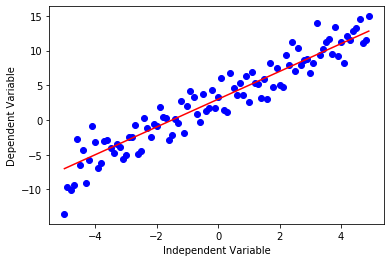

In [36]:
x = np.arange(-5.0,5.0,0.1)

y = 2*(x) + 3
y_noise = 2 * np.random.normal(size=x.size) # The graph looks lame is we don't make the blue dots move a bit off the line
ydata = y + y_noise

plt.plot(x, ydata, 'bo')
plt.plot(x,y, 'r')
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

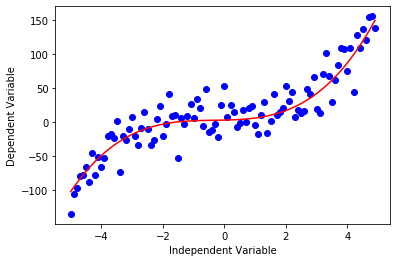

In [37]:
x = np.arange(-5.0,5.0,0.1)

y = 1*(x**3) + 1*(x**2) + 1*x + 3 # Hey, it's data with a cubic relationship
y_noise = 20 * np.random.normal(size = x.size) # Again, this looks better if all the dots are not on the curve
ydata = y + y_noise
plt.plot(x, ydata, 'bo')
plt.plot(x,y,'r')
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

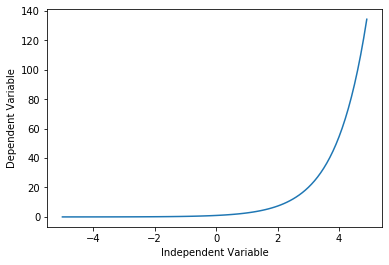

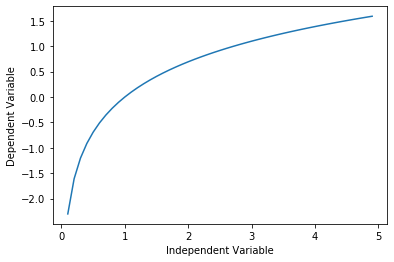

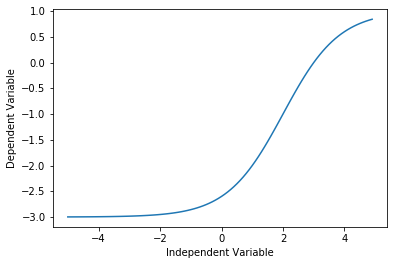

In [38]:
# Some other types of functions we might use as a model for certain types of data

X = np.arange(-5.0,5.0,0.1)
Y = np.exp(X)

plt.plot(X,Y)
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

X = np.arange(0.1,5.0,0.1)
Y = np.log(X)

plt.plot(X,Y)
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

X = np.arange(-5.0,5.0,0.1)
Y = 1 - 4/(1+np.power(3,X-2))

plt.plot(X,Y)
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

## China GDP Example

In [39]:
import pandas as pd

df = pd.read_csv("china_gdp.csv")
df.head(10)

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10
5,1965,6.970915e+10
6,1966,7.587943e+10
7,1967,7.205703e+10
8,1968,6.999350e+10
9,1969,7.871882e+10


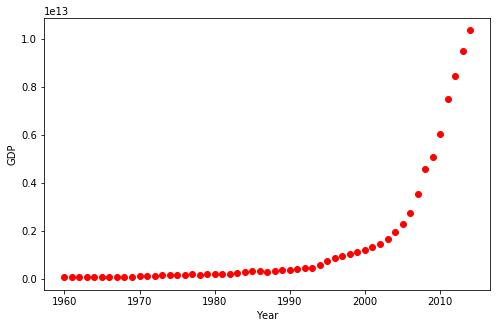

In [40]:
# Take a look at the data

plt.figure(figsize = (8,5))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.plot(x_data, y_data, 'ro')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

For the sake of learning, let us try to fit a sigmoid model to this and see how it goes!

In [41]:
def sigmoid(x, Beta_1, Beta_2):
    y = 1 / (1+np.exp(-Beta_1*(x-Beta_2)))
    return y

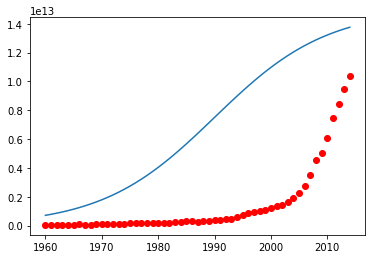

In [42]:
# Sample sigmoid curve that might work

beta_1 = 0.1
beta_2 = 1990.0

Y_pred = sigmoid(x_data, beta_1, beta_2)

plt.plot(x_data, Y_pred*15000000000000.)
plt.plot(x_data, y_data, 'ro')

This isn't really that great (which we should have suspected since an exponential model will fit this better), but the goal is still to find the best parameters for the curve.

We'll use **curve_fit** from the scipy library to adjust the parameters to get, well, a curve that fits.  (This is going to go through and minimize least squares for us to get the fit.)

In [43]:
from scipy.optimize import curve_fit

#normalize data
xdata = x_data / max(x_data)
ydata = y_data / max(y_data)

popt, pcov = curve_fit(sigmoid, xdata, ydata)

print(" beta_1 = %f, beta_2 = %f" % (popt[0], popt[1]))

 beta_1 = 690.453018, beta_2 = 0.997207


## Plotting the result!

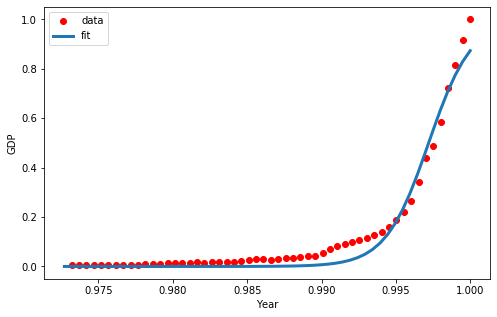

In [44]:
x = np.linspace(1960,2015,55)
x = x /max(x)
plt.figure(figsize = (8,5))
y = sigmoid (x, *popt)
plt.plot(xdata, ydata, 'ro', label = 'data')
plt.plot(x,y,linewidth = 3.0, label = 'fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

### Finally, we calculate the accuracy of this model

In [45]:
# Split the data into training and testing subsets

msk = np.random.rand(len(df)) < 0.8
train_x = xdata[msk]
test_x = xdata[~msk]
train_y = ydata[msk]
test_y = ydata[~msk]

popt, pcov = curve_fit(sigmoid, train_x, train_y)

y_hat = sigmoid (test_x, *popt)

print("Mean absolute error: %.2f" %np.mean(np.absolute(y_hat - test_y)))
print("Residual sum of squres (MSE): %.2f" %np.mean((y_hat - test_y) ** 2))
from sklearn.metrics import r2_score
print("R2-score: %.2f" % r2_score(y_hat, test_y))

Mean absolute error: 0.03
Residual sum of squres (MSE): 0.00
R2-score: 0.96


# Polynomial Regression

Examples of Polynomial regression using numpy, pandas, and matplotlib.  Toy dataset.

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

In [47]:
df = pd.read_csv("FuelConsumptionCo2.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [48]:
#Isolate some variables we care about

cdf = df[['ENGINESIZE', 'CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(10)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267
9,2.4,4,9.2,212


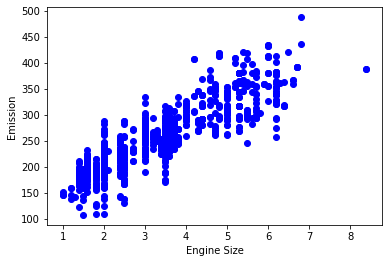

In [49]:
# Some plots to see what is going on

plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine Size")
plt.ylabel("Emission")
plt.show()

In [50]:
#Splitting test and training data

msk = np.random.rand(len(df)) < 0.8
train=cdf[msk]
test=cdf[~msk]

Next, we use the scikit-learn library to perform the polynomial regression work.  The library will let us (quickly and easily) derive the appropriate matrix of all of the polynomial combinations of the features we are trying to regress with degree less than or equal to whatever degree we specify. In this case, we'll limit our selves to quadratic (degree 2) polynomials.

In [51]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])

poly = PolynomialFeatures(degree=2)
train_x_poly = poly.fit_transform(train_x)
train_x_poly

array([[ 1.  ,  2.  ,  4.  ],
       [ 1.  ,  1.5 ,  2.25],
       [ 1.  ,  3.5 , 12.25],
       ...,
       [ 1.  ,  3.  ,  9.  ],
       [ 1.  ,  3.2 , 10.24],
       [ 1.  ,  3.2 , 10.24]])

In [52]:
# From here this problem is the same as a multiple linear regression problem, so we can use the linear regression techniques

clf = linear_model.LinearRegression()
train_y_ = clf.fit(train_x_poly, train_y)

print("Coefficients: ", clf.coef_)
print("Intercept: ", clf.intercept_)

Coefficients:  [[ 0.   48.57 -1.2 ]]
Intercept:  [109.2]


Text(0, 0.5, 'Emission')

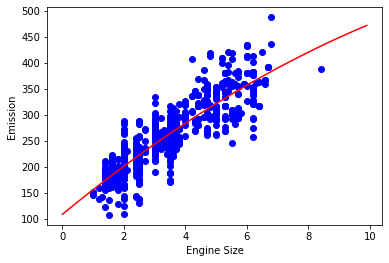

In [53]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
XX = np.arange(0.0,10.0,0.1)
yy = clf.intercept_[0]+clf.coef_[0][1]*XX+ clf.coef_[0][2]*np.power(XX,2)
plt.plot(XX,yy,'-r')
plt.xlabel("Engine Size")
plt.ylabel("Emission")

## Evaluation of the Polynomial Regression Model

In [54]:
from sklearn.metrics import r2_score

test_x_poly = poly.fit_transform(test_x)
test_y_ = clf.predict(test_x_poly)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score:  %.2f " % r2_score(test_y_ , test_y))

Mean absolute error: 22.85
Residual sum of squares (MSE): 910.49
R2-score:  0.71 


## Another Polynomial Regression model, but with degree 3 polynomial

Coefficients:  [[ 0.   48.57 -1.2 ]]
Intercept:  [131.43]
Mean absolute error: 22.79
Residual sum of squares (MSE): 903.61
R2-score: 0.71


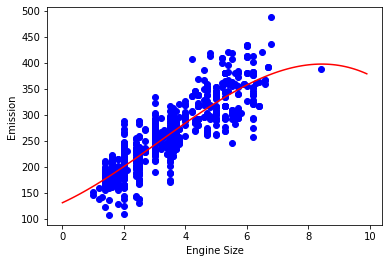

In [55]:
poly3 = PolynomialFeatures(degree=3)
train_x_poly3 = poly3.fit_transform(train_x)
clf3 = linear_model.LinearRegression()
train_y3_ = clf3.fit(train_x_poly3, train_y)

print("Coefficients: ", clf.coef_)
print("Intercept: ", clf3.intercept_)

plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
XX = np.arange(0.0,10.0,0.1)
yy = clf3.intercept_[0] + clf3.coef_[0][1]*XX + clf3.coef_[0][2]*np.power(XX,2) + clf3.coef_[0][3]*np.power(XX,3)
plt.plot(XX,yy,'-r')
plt.xlabel("Engine Size")
plt.ylabel("Emission")
test_x_poly3 = poly3.fit_transform(test_x)
test_y3_ = clf3.predict(test_x_poly3)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y3_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y3_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y3_, test_y))